In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/imtkaggleteam/netflix/NetFlix.csv


In [7]:
df = pd.read_csv('/kaggle/input/datasets/imtkaggleteam/netflix/NetFlix.csv')

# Overview of Netflix

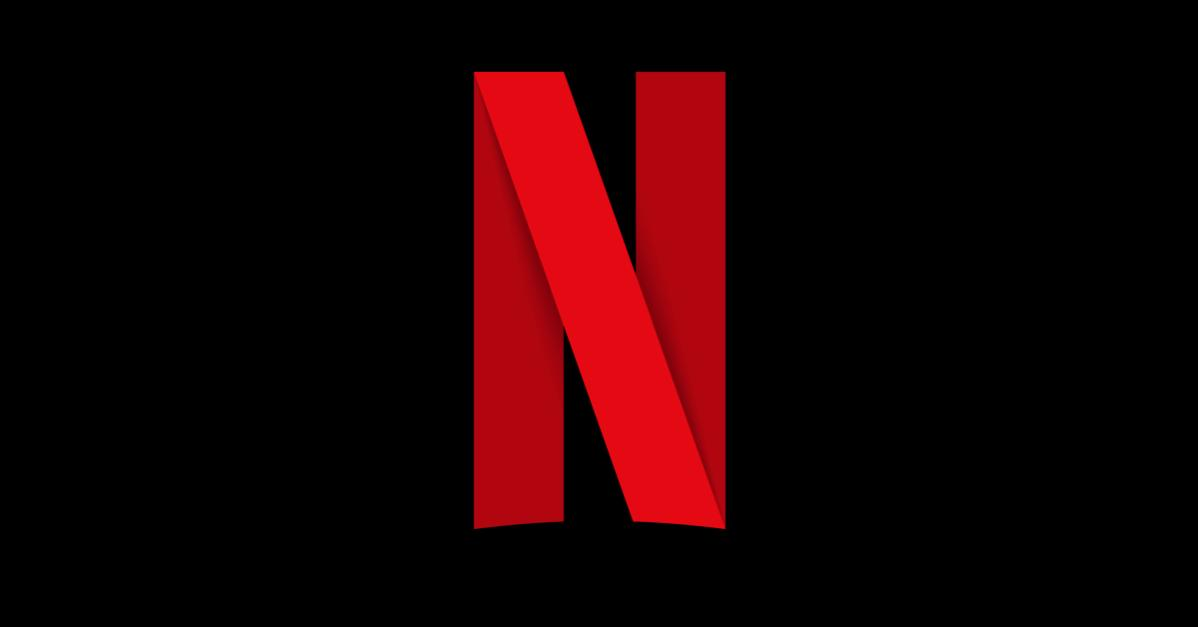
Netflix is a global online streaming platform that provides movies, TV shows, documentaries, anime, and original web series through internet-based services. Founded in 1997 by Reed Hastings and Marc Randolph, it initially started as a DVD rental service before shifting to digital streaming in 2007. Today, Netflix operates in more than 190 countries and serves millions of subscribers worldwide.

### Key Features:

* Subscription-based streaming platform
* Offers Movies, TV Shows, and Netflix Originals
* Available on mobile, TV, laptop, and tablet
* Uses AI-based recommendation systems
* Supports multiple languages and subtitles
* Produces internationally popular content

Netflix is also widely used in data analysis and machine learning projects for studying viewer behavior, recommendation systems, and entertainment trends.

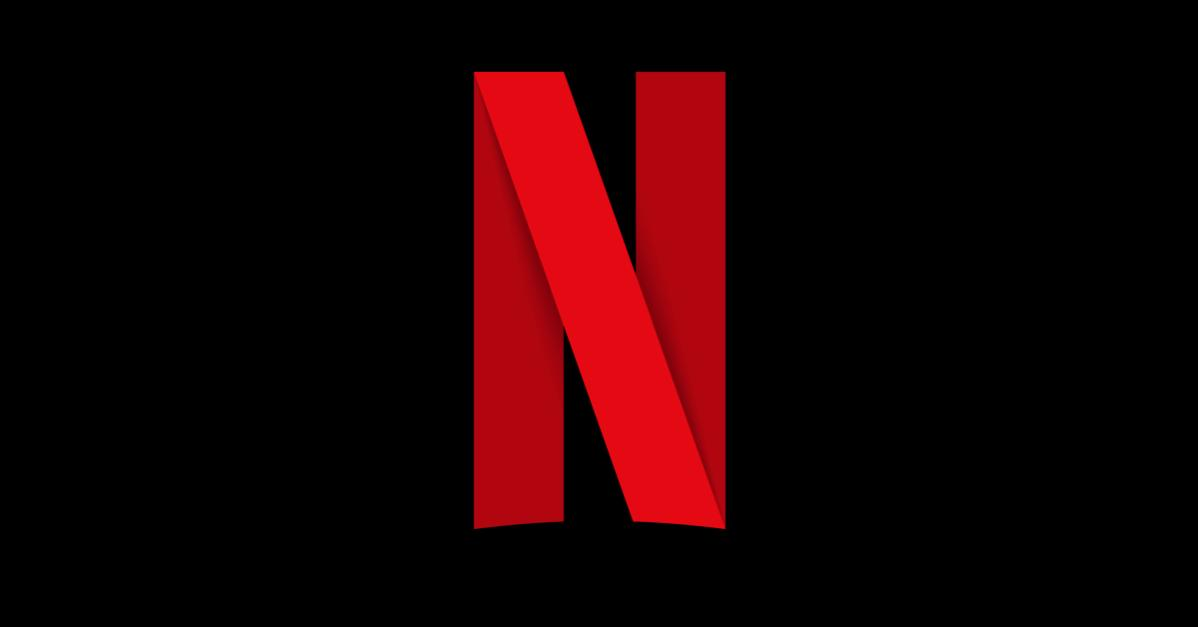

In [8]:
# import major libraries 

import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px 

# additional libraries 
import warnings
warnings.filterwarnings('ignore')

In [9]:
# overview of the dataset 

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


In [10]:
df.shape

(7787, 12)

- The dataset contains approximately 7,787 rows and 12 columns.

# Netflix Dataset Data Card

| Column Name      | Description                                                            |
| ---------------- | ---------------------------------------------------------------------- |
| **show_id**      | Unique identifier assigned to each Netflix title.                      |
| **type**         | Specifies whether the content is a Movie or TV Show.                   |
| **title**        | Name of the Netflix content.                                           |
| **director**     | Director(s) of the movie or TV show. Some values are missing.          |
| **cast**         | Main actors and actresses featured in the content.                     |
| **country**      | Country where the content was produced or released.                    |
| **date_added**   | Date on which the title was added to Netflix.                          |
| **release_year** | Original release year of the content.                                  |
| **rating**       | Audience maturity rating such as TV-MA, TV-14, PG, etc.                |
| **duration**     | Duration of movies in minutes or number of seasons for TV Shows.       |
| **genres**       | Genre/category of the content such as Drama, Comedy, Documentary, etc. |
| **description**  | Short summary or overview of the content storyline.                    |

---

# Dataset Summary

* Total Rows: **7,787**
* Total Columns: **12**
* Movies: **69%**
* TV Shows: **31%**
* Missing Values Mostly Present In:

  * Director
  * Cast
  * Country
* Most Common Rating: **TV-MA**
* Top Producing Country: **United States**
* Release Year Range: **1925 – 2021**


In [11]:
# duplicate entries 

df.duplicated().sum()

np.int64(0)

- Dataset is free from duplicacy issues.

In [12]:
# seeking info 

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   int64 
 10  genres        7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(2), object(10)
memory usage: 730.2+ KB


* The dataset contains **2 numerical columns** and **10 categorical/textual columns**.
* Most features are text-based, making the dataset suitable for content and trend analysis.
* The dataset contains some **missing values**, mainly in:

  * Director
  * Cast
  * Country
  * Date Added
* Numerical columns help analyze:

  * Release trends
  * Content duration patterns
* Data preprocessing was performed to handle completeness issues.


In [13]:
# seeking description 

df.describe()

,release_year,duration
count,7787.000000,7787.000000
mean,2013.932580,69.122769
std,8.757395,50.950743
min,1925.000000,1.000000
25%,2013.000000,2.000000
50%,2017.000000,88.000000
75%,2018.000000,106.000000
max,2021.000000,312.000000


* The release years range from **1925 to 2021**, showing that Netflix contains both modern and vintage content.
* The dataset includes classic movies released even before World War II, highlighting Netflix’s diverse historical content library.
* This wide time span helps analyze the evolution of entertainment trends across different decades.


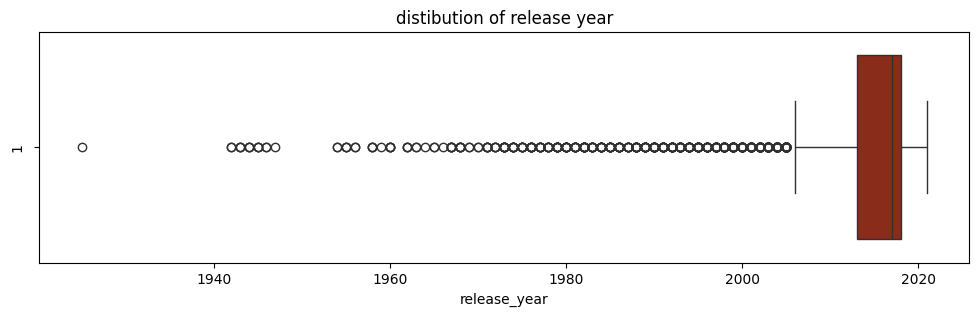

----------------------------------------------------------------------------------------------------------------------------------


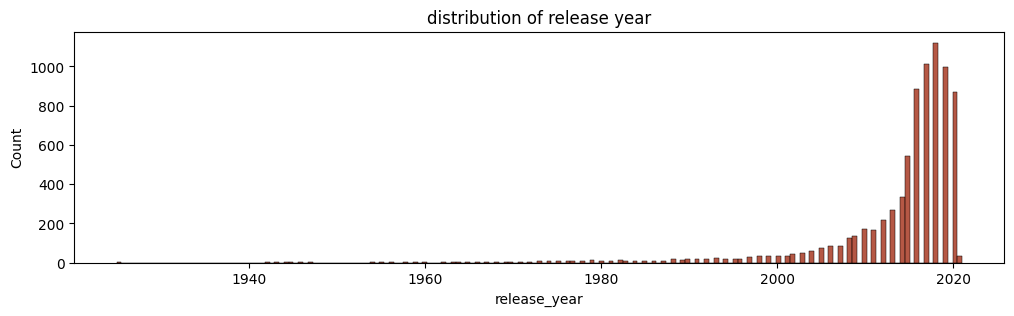

level of skewness	 -3.6191659982330684


In [14]:
# univariate analysis 
plt.figure(figsize=(12,3))
sns.boxplot(data=df,x='release_year',color='#9C2007')
plt.title('distibution of release year')
plt.ylabel('1')
plt.show()

print('-'*130)

plt.figure(figsize=(12,3))
sns.histplot(data=df,x='release_year',color='#9C2007')
plt.title('distribution of release year')
plt.show()

print('level of skewness\t',df.release_year.skew())

In [15]:
q1 = df.release_year.quantile(0.25)
q2 = df.release_year.quantile(0.50)
q3 = df.release_year.quantile(0.75)
iqr = q3 - q1 

uf = q3 + 1.5 * iqr
lf = q1 - 1.5 * iqr 

print('upper fence\t',uf)
print('lower fence\t',lf)

upper fence	 2025.5
lower fence	 2005.5


* The lower fence is around **2005**, meaning movies released before 2005 are treated as outliers due to their comparatively lower frequency in the dataset.

* This indicates that the number of movie releases significantly increased after 2005, showing rapid growth in the entertainment industry.

* One possible reason for this growth could be the rise of **CDs, DVDs, digital media, and online distribution platforms**, which made content production and accessibility easier.

* The data also shows a **right-skewed distribution**, suggesting that most Netflix content belongs to recent years, while older movies are comparatively fewer in number.


In [16]:
# completeness related issues

df.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
genres             0
description        0
dtype: int64

* The dataset contains missing values mainly in:

  * **director** → 2,389 missing values
  * **cast** → 718 missing values
  * **country** → 507 missing values
  * **date_added** → 10 missing values
  * **rating** → 7 missing values

* Columns such as **show_id, type, title, release_year, duration, genres, and description** contain complete data with no missing values.


In [17]:
# percentage 

df.isnull().mean()*100

show_id          0.000000
type             0.000000
title            0.000000
director        30.679337
cast             9.220496
country          6.510851
date_added       0.128419
release_year     0.000000
rating           0.089893
duration         0.000000
genres           0.000000
description      0.000000
dtype: float64

In [18]:
# GOLDEN RULE! 

# null values<5% --> mean, median and mode 
# null values>5% --> try to find some patterns / knn imputers
# null values>50% --> drop that column

In [19]:
df.rating.fillna(df.rating.mode().values[0],inplace=True)
df.date_added.fillna(df.date_added.mode().values[0],inplace=True)
df.country.fillna(df.country.mode().values[0],inplace=True)

In [20]:
df.isnull().sum()[df.isnull().sum()>0]

director    2389
cast         718
dtype: int64

In [21]:
df.director.fillna('unknown',inplace=True)
df.cast.fillna('unknown',inplace=True)

In [22]:
df.isnull().sum()[df.isnull().sum()>0]

Series([], dtype: int64)

Our dataset is free from any issues of completeness 

# Exploratory Data Analysis 

In [23]:
num = list(df.describe().columns)

cat = []

for i in df.columns:
    if i not in num:
        cat.append(i)

print('Categorical columns\t',cat)
print('Numerical columns\t',num)

Categorical columns	 ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'rating', 'genres', 'description']
Numerical columns	 ['release_year', 'duration']


In [33]:
# pie chart of type 

temp_type = df.type.value_counts().reset_index()

temp_type

fig = px.pie(
    temp_type,
    names='type',
    values='count',
    hole=0.5,
    title='Distribution of Movies and TV Shows on Netflix',
    color='type',
    color_discrete_map={
        'Movie': '#E50914',     # Netflix Red
        'TV Show': '#1F77B4'    # Blue
    }
)

# Layout Improvements
fig.update_traces(
    textinfo='percent+label',
    pull=[0.03, 0.03],
    marker=dict(line=dict(color='white', width=2))
)

fig.update_layout(
    title_x=0.5,
    template='plotly_white',
    font=dict(size=14),
    legend_title='Content Type'
)

# fig.show()
fig.show()

* Movies contribute nearly **69%** of the total Netflix content library, while TV Shows account for approximately **31%**.

* This indicates that Netflix primarily focuses on movie-based entertainment, with movies dominating the platform’s overall catalog.

* Comparatively, the number of TV Shows is significantly lower, suggesting that Netflix contains a much larger collection of films than episodic content.


In [25]:
temp_director = df.director.value_counts().sort_values(ascending=False).drop('unknown').head(10).reset_index()

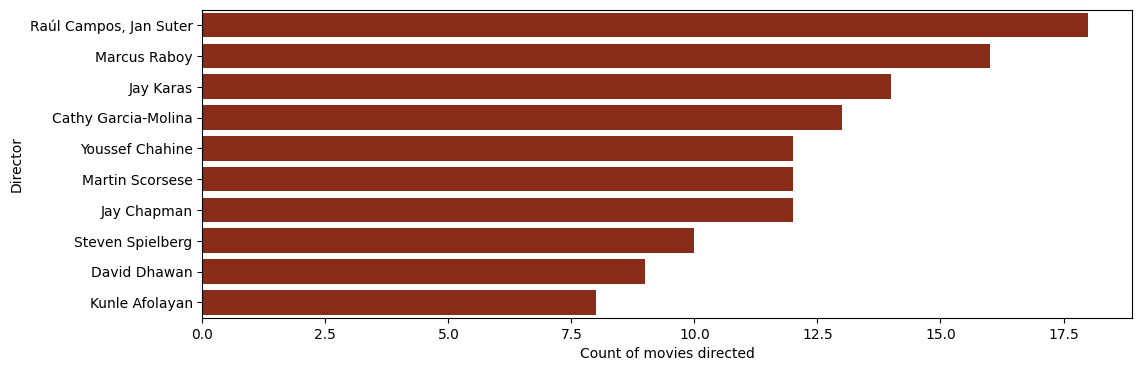

In [35]:
plt.figure(figsize=(12,4))
sns.barplot(data=temp_director,x='count',y='director',color='#9C2007')
plt.xlabel('Count of movies directed')
plt.ylabel('Director')
plt.show()

Pass 

In [27]:
temp_director
df[df.director=='Raúl Campos, Jan Suter']
df[df.director=='Marcus Raboy']
df[df.director=='David Dhawan']

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
294,s1263,Movie,Chal Mere Bhai,David Dhawan,"Sanjay Dutt, Salman Khan, Karisma Kapoor, Dali...",India,31-Dec-19,2000,TV-14,132,"Comedies, International Movies, Romantic Movies","When a secretary saves her tycoon boss's life,..."
320,s1287,Movie,Chashme Baddoor,David Dhawan,"Rishi Kapoor, Ali Zafar, Taapsee Pannu, Siddha...",India,5-Jul-20,2013,TV-14,121,"Comedies, International Movies, Music & Musicals",When pretty new neighbor Seema falls for their...
321,s1288,Movie,Chashme Buddoor,David Dhawan,"Ali Zafar, Siddharth, Divyendu Sharma, Tapsee ...",India,1-May-17,2013,TV-PG,121,"Comedies, International Movies, Music & Musicals",When pretty new neighbor Seema falls for their...
1828,s2644,Movie,Haseena Maan Jaayegi,David Dhawan,"Sanjay Dutt, Govinda, Karisma Kapoor, Pooja Ba...",India,1-Mar-18,1999,TV-PG,151,"Action & Adventure, Comedies, Dramas",A millionaire opens the door to comic complica...
2484,s3234,Movie,Judwaa,David Dhawan,"Salman Khan, Karisma Kapoor, Rambha, Kader Kha...",India,31-Dec-19,1997,TV-14,133,"Comedies, International Movies, Romantic Movies","Separated at birth, a pair of identical twins ..."
2485,s3235,Movie,Judwaa 2,David Dhawan,"Varun Dhawan, Jacqueline Fernandez, Tapsee Pan...",India,1-Mar-18,2017,TV-14,145,"Action & Adventure, Comedies, International Mo...","Separated at birth, twins Raja and Prem couldn..."
2759,s3482,Movie,Kyo Kii... Main Jhuth Nahin Bolta,David Dhawan,"Govinda, Mohnish Bahl, Sharad Kapoor, Satish K...",India,16-May-19,2001,TV-PG,150,"Comedies, International Movies, Sci-Fi & Fantasy",The life and career of a lawyer are thrown int...
3195,s3875,Movie,Maine Pyaar Kyun Kiya,David Dhawan,"Salman Khan, Sushmita Sen, Sohail Khan, Katrin...",India,31-Dec-19,2005,TV-14,137,"Comedies, International Movies, Music & Musicals","After lying to his girlfriend, orthopedic surg..."
3639,s4274,Movie,Mujhse Shaadi Karogi,David Dhawan,"Rajpal Yadav, Amrish Puri, Kader Khan, Shashi ...",India,31-Dec-19,2004,TV-PG,158,"Comedies, International Movies, Romantic Movies","Samir must overcome a hostile horoscope, a hot..."


In [28]:
df.cast.str.split(',',expand=True)

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,João Miguel,Bianca Comparato,Michel Gomes,Rodolfo Valente,Vaneza Oliveira,Rafael Lozano,Viviane Porto,Mel Fronckowiak,Sergio Mamberti,Zezé Motta,...,None,None,None,None,None,None,None,None,None,None
1,Rajneesh Duggal,Adah Sharma,Indraneil Sengupta,Anjori Alagh,Rajendranath Zutshi,Vipin Sharma,Amin Hajee,Shri Vallabh Vyas,None,None,...,None,None,None,None,None,None,None,None,None,None
2,Reza Rahadian,Bunga Citra Lestari,Tara Basro,Chelsea Islan,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
3,Alan Ritchson,Darin Brooks,James Cade,Rob Ramsay,Chris Romano,Frankie Shaw,Omari Newton,Ed Marinaro,Dhani Jones,Ed Amatrudo,...,None,None,None,None,None,None,None,None,None,None
4,David Attenborough,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7782,unknown,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
7783,Nobuhiko Okamoto,Jun Fukuyama,Kana Hanazawa,Kazuya Nakai,Koji Yusa,Yuki Kaji,Eri Kitamura,Ayahi Takagaki,Rina Satou,Daisuke Ono,...,None,None,None,None,None,None,None,None,None,None
7784,Léa Seydoux,Adèle Exarchopoulos,Salim Kechiouche,Aurélien Recoing,Catherine Salée,Benjamin Siksou,Mona Walravens,Alma Jodorowsky,Jérémie Laheurte,Anne Loiret,...,None,None,None,None,None,None,None,None,None,None
7785,Cate Blanchett,Sally Hawkins,Alec Baldwin,Louis C.K.,Bobby Cannavale,Andrew Dice Clay,Peter Sarsgaard,Michael Stuhlbarg,Tammy Blanchard,Max Casella,...,None,None,None,None,None,None,None,None,None,None


there are some movies in our datasets which contains upto 50 leads 

In [29]:
df.cast.str.split(',',expand=True).iloc[:,0:2]

,0,1
0,João Miguel,Bianca Comparato
1,Rajneesh Duggal,Adah Sharma
2,Reza Rahadian,Bunga Citra Lestari
3,Alan Ritchson,Darin Brooks
4,David Attenborough,None
...,...,...
7782,unknown,None
7783,Nobuhiko Okamoto,Jun Fukuyama
7784,Léa Seydoux,Adèle Exarchopoulos
7785,Cate Blanchett,Sally Hawkins


In [30]:
temp_lead = df.cast.str.split(',',expand=True)[0].value_counts().drop('unknown').head(15).reset_index().rename({
    0:'lead_actor','count':'no_movies'},axis=1)

In [31]:
temp_second_lead = df.cast.str.split(',',expand=True)[1].value_counts().head(10).reset_index().rename({
    1:'secondary_lead','count':'no_movies'},axis=1)

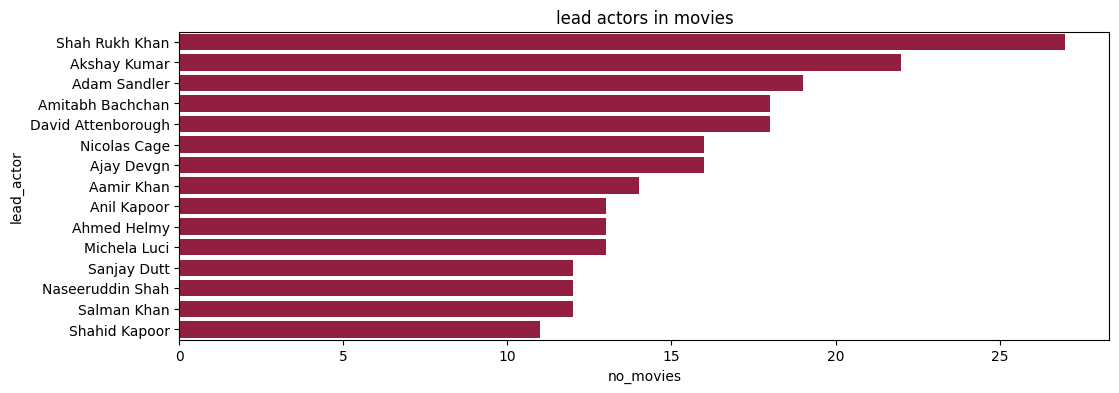

In [32]:
# barchart on primary lead 

plt.figure(figsize=(12,4))
sns.barplot(data=temp_lead, y= 'lead_actor',x='no_movies',color='#A50C36')
plt.title('lead actors in movies')
plt.show()

* Most of the actors appearing in the top list are Indian actors, indicating the strong presence and influence of Indian cinema content on Netflix.

* Shah Rukh Khan has the highest number of movie appearances in the dataset, followed by Akshay Kumar. This highlights the popularity of Bollywood content on the platform.

* The chart suggests that Indian actors tend to appear in a larger number of films compared to many Hollywood actors, possibly due to the higher volume of movie production in the Indian film industry.

* Actors such as Adam Sandler and Nicolas Cage also maintain a strong presence, representing Hollywood’s contribution to Netflix’s movie catalog.

* Overall, the analysis reflects Netflix’s growing focus on international and regional entertainment content, especially from India.


In [37]:
print('cat ',cat)
print('num ',num)

cat  ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'rating', 'genres', 'description']
num  ['release_year', 'duration']


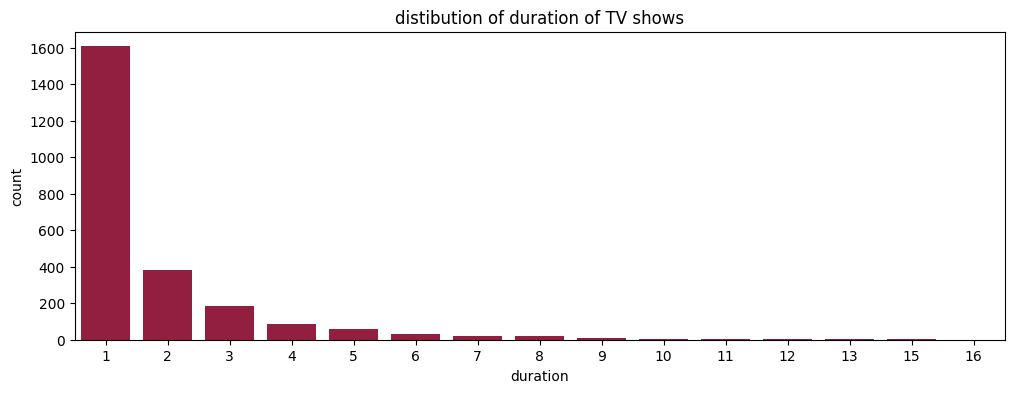

In [46]:
# duration 

tv_show = df[df.type=='TV Show']

tv_show

plt.figure(figsize=(12,4))
sns.countplot(data=tv_show,x='duration',color='#A50C36')
plt.title('distibution of duration of TV shows')
plt.show()

### Information and Insights

* The distribution of TV shows by number of seasons is highly right-skewed, indicating that the majority of shows on Netflix consist of only a single season. This suggests that limited-series content and short-lived productions dominate the platform’s catalog.

* Only a very small number of shows extend to a high season count, with the maximum observed value reaching 16 seasons. Such long-running series are rare compared to the overall dataset.

* The graph shows a gradual decline in the number of shows from 1 to around 4 seasons. After the 4-season mark, the frequency drops significantly, indicating that relatively few shows continue beyond this point.

* Based on the distribution pattern, 4 seasons can be considered an approximate industry benchmark for successful TV show continuity, as sustaining a series beyond four seasons appears to be comparatively uncommon on Netflix.

* The trend also reflects audience retention and production challenges in the streaming industry, where many shows are either designed as short-format content or are discontinued after a few seasons due to performance, budget, or engagement factors.


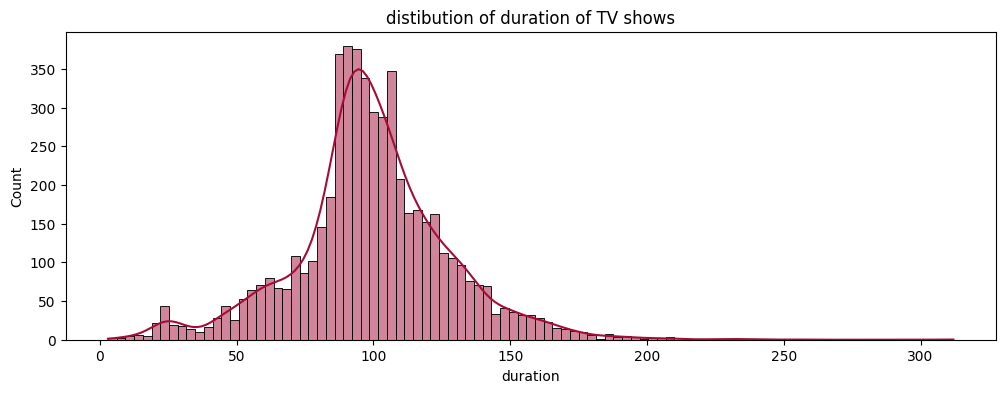

------------------------------------------------------------------------------------------------------------------------------------------------------


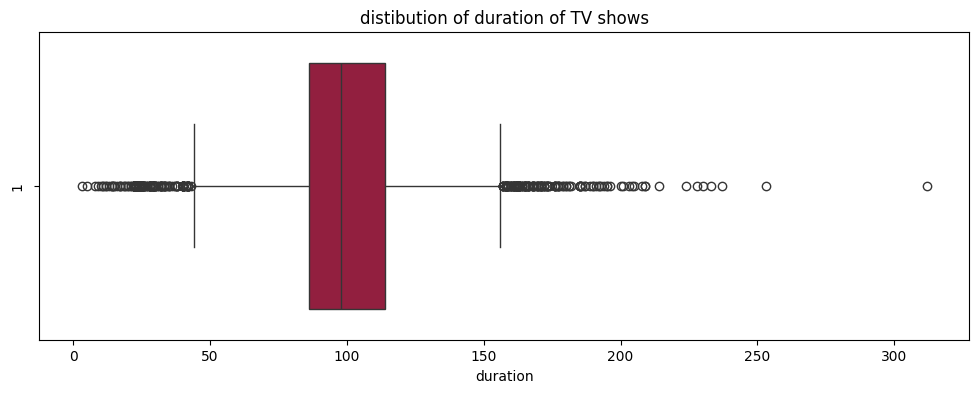

Skewness  0.19102984870544784


In [59]:

Movie = df[df.type=='Movie']

Movie

plt.figure(figsize=(12,4))
sns.histplot(data=Movie,x='duration',color='#A50C36',kde=True)
plt.title('distibution of duration of TV shows')
plt.show()
print('-'*150)

plt.figure(figsize=(12,4))
sns.boxplot(data=Movie,x='duration',color='#A50C36')
plt.title('distibution of duration of TV shows')
plt.ylabel(1)
plt.show()

print("Skewness ",Movie.duration.skew())

### Information and Insights

* The majority of movies on Netflix have durations ranging between 50 and 150 minutes, indicating that standard feature-length films dominate the platform’s movie catalog.

* The distribution appears to be approximately normal (bell-shaped), suggesting that most movie durations are concentrated around the average runtime, with fewer movies having extremely short or extremely long durations.

* A very small number of movies extend beyond 200 minutes, showing that exceptionally long films are rare on Netflix.

* The dataset also contains an extreme outlier with a duration exceeding 300 minutes. This unusually long runtime slightly distorts the overall distribution and contributes to the minor skewness observed in the graph.

* Apart from these outliers, the duration pattern remains relatively balanced and consistent, reflecting industry-standard movie runtimes designed to maintain audience engagement and viewing convenience.


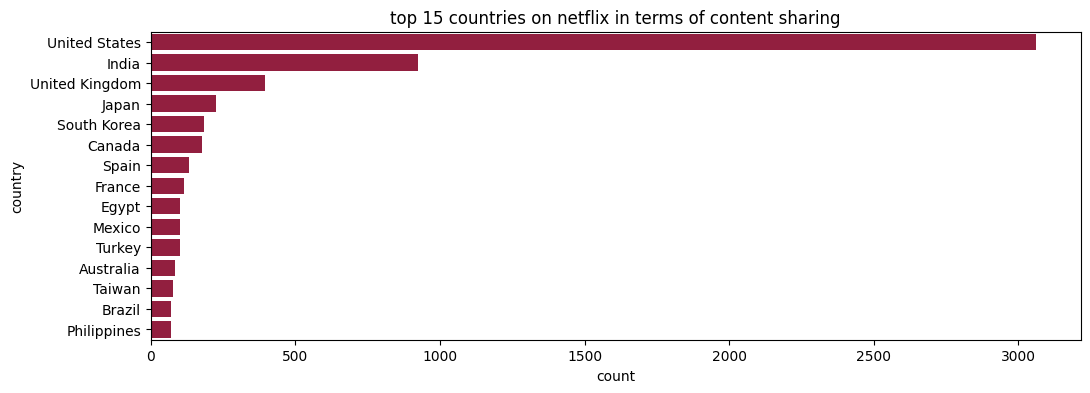

In [74]:
temp_country = df.country.value_counts().reset_index().head(15)

plt.figure(figsize=(12,4))
sns.barplot(data=temp_country,y='country',x='count',color='#A50C36')
plt.title('top 15 countries on netflix in terms of content sharing')
plt.show()

### Information and Insights

* The United States ranks highest in terms of content contribution on Netflix, followed by India. This highlights the dominance of these two countries in Netflix’s global content library.

* Despite entering the large-scale streaming market later than the United States, India has emerged as a strong competitor in content production and distribution. This indicates that India is a highly potential and rapidly growing market for Netflix, driven by its massive audience base, diverse regional cinema, and increasing digital consumption.

* Japan and South Korea hold the 4th and 5th positions respectively. Although their overall content volume is lower compared to the top countries, both nations are globally recognized for producing high-quality and culturally influential content.

* Japanese anime and South Korean dramas have gained strong international popularity, significantly contributing to Netflix’s global audience engagement and subscriber growth.

* The comparatively lower content volume from Japan and South Korea suggests an opportunity for Netflix to further invest in and expand collaborations within these markets, as both countries possess strong storytelling industries and highly exportable entertainment content.


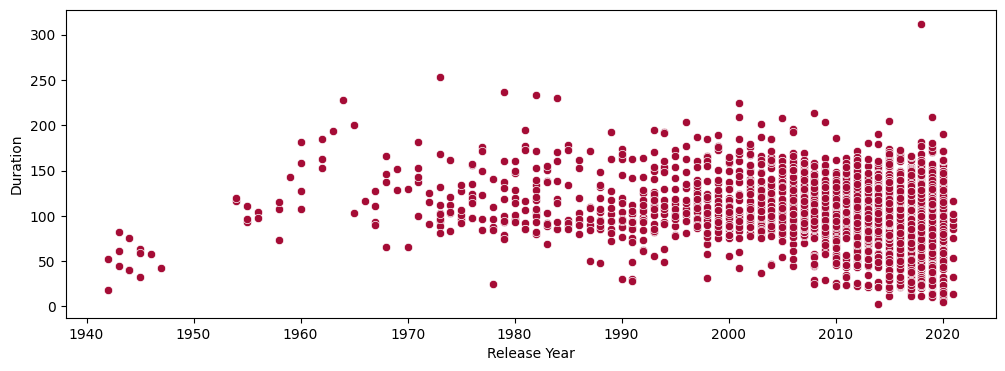

------------------------------------------------------------------------------------------------------------------------------------------------------


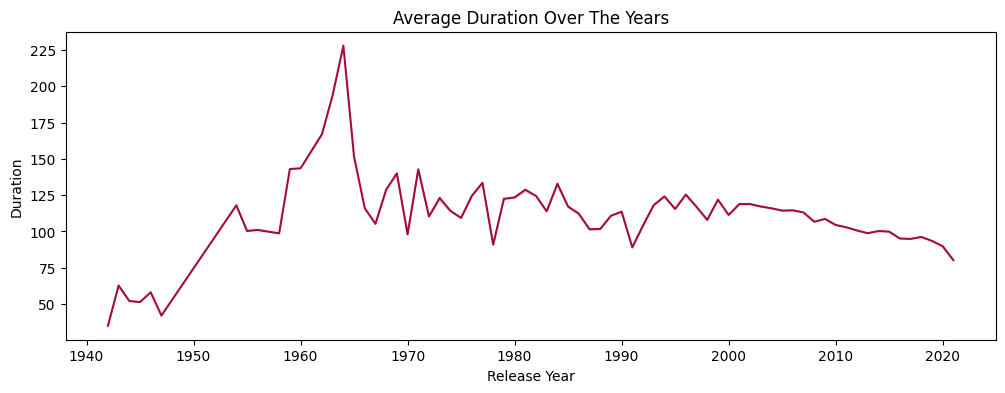

In [86]:
# trend graph between release-year and duration 
plt.figure(figsize=(12,4))
sns.scatterplot(data=Movie,x='release_year',y='duration',color='#A50C36')
plt.xlabel('Release Year')
plt.ylabel('Duration')
plt.show()
print('-'*150)
plt.figure(figsize=(12,4))
sns.lineplot(data=Movie,x='release_year',y='duration',ci=False,color='#A50C36')
plt.title('average duration over the years'.title())
plt.xlabel('Release Year')
plt.ylabel('Duration')
plt.show()

### Information and Insights

* During the 1940s and early 1950s, the average movie duration was relatively short. One possible reason could be the technological and storage limitations of that era, along with different audience consumption patterns and production styles.

* From the late 1950s to the mid-1960s, movie durations increased significantly, reaching a peak of around 225 minutes in the 1960s. This period reflects the popularity of long-form cinematic storytelling and epic-style productions.

* After the 1970s, the graph becomes comparatively stable, indicating that movie durations started following a more standardized format. Most films during this period remained close to the 100–130 minute range, which aligns with the industry’s preferred runtime for audience engagement and theatrical scheduling.

* The fluctuations between the 1970s and 2000s are relatively moderate, suggesting consistency in movie production trends and viewer preferences.

* After the year 2000, a gradual decline in average movie duration can be observed. This may reflect changing audience behavior, faster-paced storytelling, the rise of digital entertainment platforms, and shorter attention spans in modern media consumption.

* Overall, the trend demonstrates how movie durations have evolved over time in response to technological advancements, industry standards, and shifts in audience preferences.


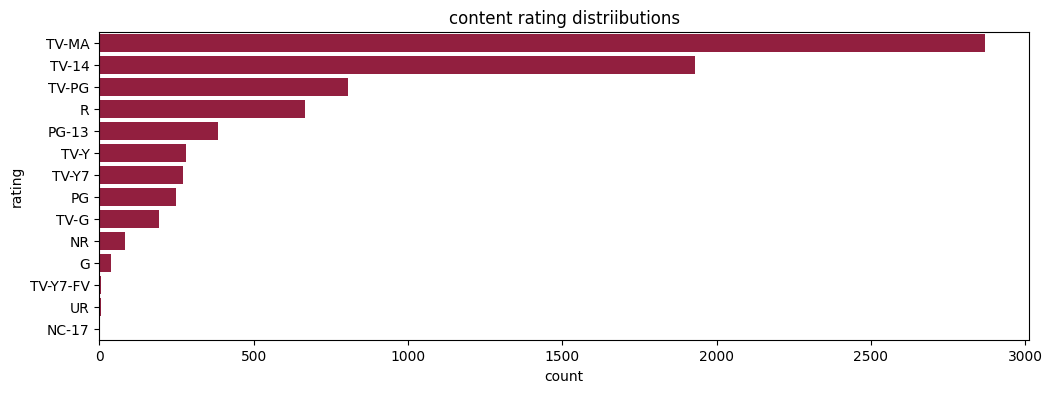

In [94]:
plt.figure(figsize=(12,4))
sns.countplot(data=df,y='rating',order=df['rating'].value_counts().index,color='#A50C36')
plt.title('content rating distriibutions')
plt.show()

### Short Understanding of Netflix Content Ratings

* **TV-MA** → Content made for mature audiences only (18+). It may contain strong violence, adult themes, or explicit language.
* **TV-14** → Suitable for viewers above 14 years. May include moderate violence, strong language, or mature themes.
* **TV-PG** → Parental guidance suggested. Suitable for teenagers and families with some supervision.
* **R** → Restricted content. Usually meant for adults, and younger viewers require parental guidance.
* **PG-13** → Parents strongly cautioned. Some content may not be suitable for children under 13.
* **TV-Y / TV-Y7** → Content specially designed for children and young audiences.
* **PG** → Family-friendly content with mild themes or language.
* **TV-G / G** → General audience content, safe for almost all age groups.
* **NC-17** → Strictly adults-only content.
* **NR / UR** → Not officially rated or unrated content.

### Information and Insights

* The majority of Netflix content falls under the **TV-MA** category, indicating that the platform primarily focuses on mature audience entertainment such as crime, thriller, drama, and action-based content.

* **TV-14** is the second most common rating, showing that Netflix also targets teenage and young adult audiences with moderately mature content.

* Ratings such as **TV-PG**, **PG-13**, and **R** have moderate representation, suggesting a balanced mix of family-oriented and adult-focused entertainment.

* Very few titles belong to categories like **G**, **TV-G**, and **TV-Y**, which indicates that children-focused content forms a smaller portion of Netflix’s overall library.

* The dominance of mature ratings suggests that Netflix’s content strategy is heavily centered around adult and young-adult viewers, who form a major share of the streaming audience.


Text(0.5, 1.0, 'Most popular genres')

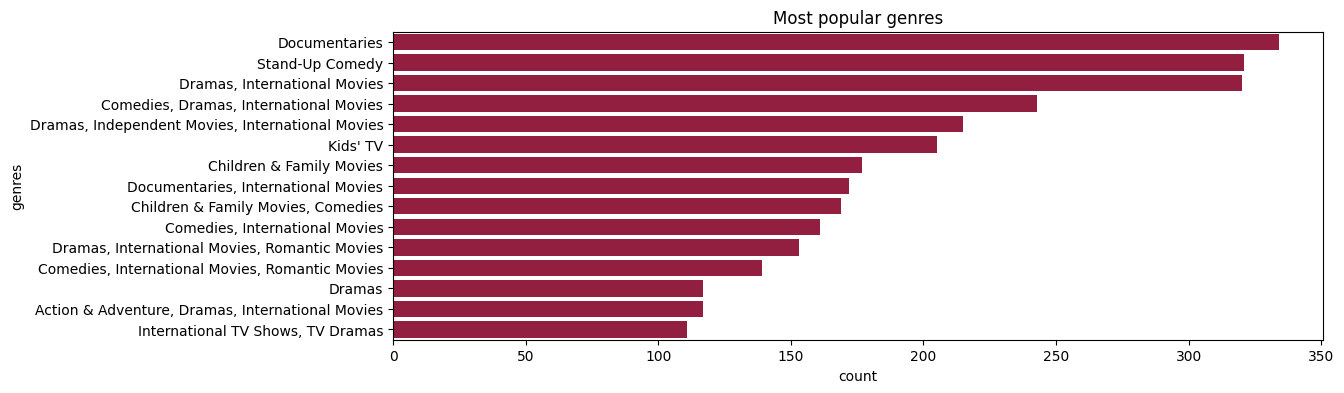

In [107]:
temp_genre = df.genres.value_counts().sort_values(ascending=False).head(15).reset_index()
plt.figure(figsize=(12,4))
sns.barplot(data=temp_genre,x='count',y='genres',color='#A50C36')
plt.title('Most popular genres')

### Information and Insights

* Genres such as documentaries, drama, and comedy dominate the Netflix platform, indicating that viewers strongly prefer informative, emotional, and entertainment-focused content.

* Drama remains one of the most popular categories due to its wide audience appeal and ability to cover diverse storytelling themes such as romance, crime, thriller, and real-life situations.

* Comedy content also holds a significant share, reflecting the increasing demand for light-hearted and binge-worthy entertainment among viewers.

* The strong presence of documentaries suggests that audiences are increasingly interested in educational, investigative, and real-world content alongside traditional entertainment.

* International genres are continuously growing on Netflix, which highlights the platform’s global expansion strategy and the increasing participation of multiple countries in content creation.

* The rise of international content indicates that audiences are becoming more open to foreign-language films and series, especially with the growing popularity of Korean dramas, Japanese anime, Indian cinema, and European productions.

* This trend demonstrates that Netflix is evolving from a region-specific streaming platform into a truly global entertainment ecosystem with culturally diverse content offerings.


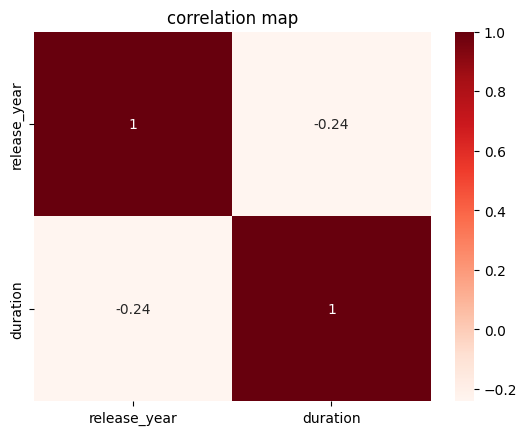

In [113]:
# corr map 

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='Reds')
plt.title('correlation map')
plt.show()

### Information and Insights

* The correlation matrix shows the relationship between numerical variables in the dataset, helping identify whether variables move together positively or negatively.

* A correlation value of **-0.24** is observed between movie duration and release year. This indicates a weak negative correlation between the two variables.

* The negative relationship suggests that, over time, average movie durations have gradually decreased, meaning modern movies tend to be shorter compared to older films.

* Although the correlation is not very strong, it still reflects a noticeable trend in the entertainment industry toward more compact and faster-paced storytelling.

* This decline in movie length may be influenced by changing audience behavior, reduced attention spans, streaming platform optimization, and the growing preference for shorter and binge-friendly content formats.


# Netflix Exploratory Data Analysis (EDA) Report

## Summary

This Exploratory Data Analysis (EDA) project was conducted on the Netflix dataset to identify content trends, audience preferences, genre distribution, runtime patterns, ratings, and country-wise contributions. The analysis highlights how Netflix has evolved into a globally dominant streaming platform with a strong focus on movies, international content, and mature audience entertainment.

The dataset reveals that movies form the majority of Netflix’s content library, contributing nearly 69% of the total catalog, while TV Shows account for approximately 31%. This suggests that Netflix primarily emphasizes movie-based entertainment over episodic content.

The analysis also highlights the strong influence of Indian entertainment on Netflix. Many of the most frequently appearing actors in the dataset are Indian actors, with Shah Rukh Khan and Akshay Kumar leading in movie appearances. This indicates Netflix’s growing investment in Bollywood and Indian regional cinema.

TV Show season analysis demonstrates that most shows contain only one season, creating a highly right-skewed distribution. Very few series continue beyond four seasons, and only a handful reach extremely high season counts such as 16 seasons. This suggests that limited series and short-format storytelling dominate the platform.

Movie duration analysis shows that most movies range between 50 and 150 minutes, following an approximately bell-shaped distribution. A small number of outliers exceed 300 minutes. Historical trends indicate that movie durations increased significantly during the 1960s before stabilizing around industry-standard runtimes of approximately two hours. Recent years show a gradual decline in average movie duration, reflecting modern audience preferences for shorter and faster-paced content.

The country-wise analysis identifies the United States as the largest contributor to Netflix content, followed closely by India. Despite entering the streaming ecosystem later, India has emerged as a major competitor and a high-potential market for Netflix. Japan and South Korea also contribute significantly through globally popular anime and drama content, highlighting the importance of international entertainment.

Content rating analysis reveals that TV-MA and TV-14 dominate the platform, suggesting that Netflix mainly targets mature and young-adult audiences. Family and children-focused content forms a comparatively smaller share of the catalog.

Genre analysis indicates that documentaries, drama, and comedy are the most dominant genres on Netflix. The increasing growth of international genres demonstrates rising global participation in Netflix content production and increasing acceptance of foreign-language entertainment among audiences worldwide.

Correlation analysis between release year and movie duration shows a weak negative relationship (-0.24), suggesting that movie lengths have gradually become shorter over time.

---

# Conclusion

The Netflix EDA reveals that the platform has successfully positioned itself as a global entertainment ecosystem driven primarily by movies, mature audience content, and international storytelling.

Movies remain the dominant content type on Netflix, while TV Shows tend to follow shorter season formats, reflecting modern streaming consumption behavior. The platform strongly focuses on adult and young-adult audiences, as indicated by the dominance of TV-MA and TV-14 ratings.

The analysis also demonstrates Netflix’s growing dependence on international markets, particularly India, South Korea, and Japan. Indian cinema contributes heavily to the platform’s actor and movie distribution, while Korean dramas and Japanese anime continue to strengthen global engagement.

Another key observation is the evolution of movie durations over time. Older films were generally longer, whereas modern content is becoming shorter and more optimized for streaming audiences with changing viewing habits.

Overall, the analysis highlights Netflix’s strategy of combining globally diverse content, regional entertainment industries, and audience-driven storytelling to maintain its dominance in the streaming industry.


# Advisories

* The analysis is based only on the available Netflix dataset and may not represent the complete real-time Netflix catalog.

* Some records may contain missing, inconsistent, or outdated information, which can slightly affect the accuracy of the analysis.

* Correlation values indicate relationships between variables but do not confirm causation. For example, shorter movie durations over time may be influenced by multiple external factors.

* Content availability on Netflix varies across countries and regions, therefore the findings may differ for different geographic audiences.

* Actor frequency analysis represents the number of appearances in the dataset and should not be interpreted as a direct measure of popularity or success.

* Genre and rating distributions may change over time as Netflix continuously updates and expands its content library.

* The insights generated from this EDA should be considered exploratory rather than predictive, as no advanced forecasting or machine learning models were applied.

* Certain extreme values and outliers, such as unusually long movie durations, may slightly impact statistical distributions and visual interpretations.

* International content growth observed in the dataset reflects increasing global participation, but it may also depend on dataset collection methods and regional availability.

* The report is intended for educational and analytical purposes to understand trends, patterns, and viewer-oriented strategies within Netflix content.
